In [1]:
import torch 
import sys 
# sys.path.append("/om2/user/msaddler/auditoryutil")
# import util_torch
import src.util_filters as util_filters

import numpy as np

from src.time_domain_cochleagram import TimeDomainCochleagram
import src.audio_transforms as at
import src.custom_modules as cm
import torchaudio.transforms as T
# import src.audio

%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
### Setup config args
import yaml

path = 'config/binaural_attn/word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

audio_config = config['audio']
audio_config

## get 50Hz cutoff 

path = "config/binaural_attn/word_task_half_co_loc_v09_50Hz_cutoff.yaml"
low_config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)
low_audio_config = low_config['audio']


### Want to compare against torchaudio lowpass filtering 

In [5]:
## manually add IHCLowpassFilter from util_torch 

## these will be added to src.audio_transforms.py


class FIRFilterbank(torch.nn.Module):
    def __init__(self, fir, dtype=torch.float32, **kwargs_conv1d):
        """
        FIR filterbank

        Args
        ----
        fir (list or np.ndarray or torch.Tensor):
            Filter coefficients. Shape (n_taps,) or (n_filters, n_taps)
        dtype (torch.dtype):
            Data type to cast `fir` to in case it is not a `torch.Tensor`
        kwargs_conv1d (kwargs):
            Keyword arguments passed on to torch.nn.functional.conv1d
            (must not include `groups`, which is used for batching)
        """
        super().__init__()
        if not isinstance(fir, (list, np.ndarray, torch.Tensor)):
            raise TypeError(
                "fir must be list, np.ndarray or torch.Tensor, got "
                f"{fir.__class__.__name__}"
            )
        if isinstance(fir, (list, np.ndarray)):
            fir = torch.tensor(fir, dtype=dtype)
        if fir.ndim not in [1, 2]:
            raise ValueError(
                "fir must be one- or two-dimensional with shape (n_taps,) or "
                f"(n_filters, n_taps), got shape {fir.shape}"
            )
        self.register_buffer("fir", fir)
        self.kwargs_conv1d = kwargs_conv1d

    def forward(self, x, batching=False):
        """
        Filter input signal

        Args
        ----
        x (torch.Tensor): Input signal
        batching (bool):
            If `True`, the input is assumed to have shape (..., n_filters, time)
            and each channel is filtered with its own filter

        Returns
        -------
        y (torch.Tensor): Filtered signal
        """
        y = x
        if batching:
            util_filters._batching_check(y, self.fir)
        else:
            y = y.unsqueeze(-2)
        unflatten_shape = y.shape[:-2]
        y = torch.flatten(y, start_dim=0, end_dim=-2 - 1)
        y = torch.nn.functional.conv1d(
            input=torch.nn.functional.pad(y, (self.fir.shape[-1] - 1, 0)),
            weight=self.fir.flip(-1).view(-1, 1, self.fir.shape[-1]),
            **self.kwargs_conv1d,
            groups=y.shape[-2] if batching else 1,
        )
        # y = torch.unflatten(y, 0, unflatten_shape)
        y = y.view(*unflatten_shape, *y.shape[-2:])
        if self.fir.ndim == 1:
            y = y.squeeze(-2)
        return y


class IHCLowpassFilter(FIRFilterbank):
    def __init__(
        self,
        sr_input=20e3,
        sr_output=10e3,
        fir_dur=0.05,
        cutoff=3e3,
        order=7,
        dtype=torch.float32,
    ):
        """ """
        fir = util_filters.ihc_lowpass_filter_fir(
            sr=sr_input,
            fir_dur=fir_dur,
            cutoff=cutoff,
            order=order,
        )
        stride = int(sr_input / sr_output)
        msg = f"{sr_input=} and {sr_output=} require non-integer stride"
        assert np.isclose(stride, sr_input / sr_output), msg
        super().__init__(fir, dtype=dtype, stride=stride)


## Init cochleagram functionality

In [6]:
cgram_kwargs = audio_config['rep_kwargs']
cgram_kwargs['binaural'] = True
cgram_kwargs['rep_on_gpu'] = True
# cgram_kwargs['center_crop'] = False

low_cgram_kwargs = low_audio_config['rep_kwargs']
low_cgram_kwargs['binaural'] = True
low_cgram_kwargs['rep_on_gpu'] = True


In [7]:
cgram_kwargs

{'sr': 44100,
 'env_sr': 10000,
 'n_channels': 40,
 'low_lim': 40,
 'use_pad': True,
 'binaural': True,
 'rep_on_gpu': True,
 'center_crop': True,
 'out_dur': 2,
 'impulse_len': 0.25,
 'env_extraction_type': 'Half-wave Rectification',
 'downsampling_type': 'TorchTransformsResample',
 'downsampling_kwargs': {'lowpass_filter_width': 64,
  'rolloff': 0.9475937167399596,
  'resampling_method': 'kaiser_window',
  'beta': 14.769656459379492}}

In [8]:
low_cgram_kwargs

{'sr': 44100,
 'env_sr': 10000,
 'n_channels': 40,
 'low_lim': 40,
 'use_pad': True,
 'binaural': True,
 'rep_on_gpu': True,
 'center_crop': True,
 'out_dur': 2,
 'impulse_len': 0.25,
 'env_extraction_type': 'Half-wave Rectification',
 'downsampling_type': 'IHCLowpassFilter',
 'downsampling_kwargs': {'cutoff': 50, 'order': 7}}

In [9]:
sr = cgram_kwargs['sr']
env_sr = cgram_kwargs['env_sr']
use_pad = cgram_kwargs['use_pad']
# Define cochlear filters
coch_filter_kwargs = {'sr':sr,
                            'env_sr': env_sr,
                            'n_channels': cgram_kwargs['n_channels'],
                            'low_lim': cgram_kwargs['low_lim'],
                            }
# Define an envelope extraction operation in Forward
# Define a downsampling operation
if isinstance(cgram_kwargs['downsampling_type'], str):
    downsampling = at.downsampling_reps[cgram_kwargs['downsampling_type']]
else:
    downsampling = cgram_kwargs['downsampling_type']
downsampling_kwargs = cgram_kwargs['downsampling_kwargs']
downsampling_op = downsampling(sr,
                                            env_sr,
                                            **downsampling_kwargs,
                                            )
# Compression is applied as a separate transform to be consistent with Spectrograms
# Define cochleagram

Cochleagram = TimeDomainCochleagram(coch_filter_kwargs,
                                        downsampling_op,
                                        compression=None,
                                        **cgram_kwargs).cuda()


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [10]:


# low_cutoff cochleagram
lp_coch_filter_kwargs = coch_filter_kwargs.copy()
lp_coch_filter_kwargs['sr'] = 50_000


sr = low_cgram_kwargs['sr']
env_sr = low_cgram_kwargs['env_sr']
use_pad = low_cgram_kwargs['use_pad']
# Define cochlear filters
coch_filter_kwargs = {'sr':sr,
                            'env_sr': env_sr,
                            'n_channels': low_cgram_kwargs['n_channels'],
                            'low_lim': low_cgram_kwargs['low_lim'],
                            }
# Define an envelope extraction operation in Forward
# Define a downsampling operation
if isinstance(low_cgram_kwargs['downsampling_type'], str):
    downsampling = at.downsampling_reps[low_cgram_kwargs['downsampling_type']]
else:
    downsampling = low_cgram_kwargs['downsampling_type']
downsampling_kwargs = low_cgram_kwargs['downsampling_kwargs']
downsampling_op = downsampling(
                                            **downsampling_kwargs,
                                            )
# Compression is applied as a separate transform to be consistent with Spectrograms
# Define cochleagram



saddler_IHC_lowpass = IHCLowpassFilter(sr_input=50_000, sr_output=10000, cutoff=50, order=7)
lc_Cochleagram = TimeDomainCochleagram(lp_coch_filter_kwargs,
                                       saddler_IHC_lowpass,
                                        compression=None,
                                        **low_cgram_kwargs).cuda()

center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [11]:
resample =  at.Resample(44_100, 50_000, 
                              lowpass_filter_width = 64,
      rolloff = 0.9475937167399596,
      resampling_method = "kaiser_window",
      beta = 14.769656459379492)

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


In [31]:
### load speech signal
import librosa
from pathlib import Path
eg_path = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2023/sounds/condition_00/").glob("*.wav")
eg_path = next(eg_path)

eg_audio = torch.from_numpy(librosa.load(eg_path, sr=44100)[0]).unsqueeze(0)
# eg_audio_50 = torch.from_numpy(librosa.load(eg_path, sr=50_000)[0]).unsqueeze(0)
# 
# crop audio to last 2 seconds
eg_audio = eg_audio[..., -2*44100:]
# eg_audio_50 = eg_audio_50[..., -2*50_000:]

# eg_audio = at.DuplicateChannel(2)(eg_audio, None)[0].cuda().unsqueeze(0)
# # eg_audio_50 = at.DuplicateChannel(2)(eg_audio_50, None)[0].cuda().unsqueeze(0)
# eg_audio_50, _ = resample(eg_audio.cpu(), None)
# eg_audio_50 = eg_audio_50.cuda()

#### Time cpu upsampling

In [38]:
%%timeit

resample = at.Resample(44_100, 50_000, 
                        lowpass_filter_width = 64,
                        rolloff = 0.9475937167399596,
                        resampling_method = "kaiser_window",
                        beta = 14.769656459379492)
eg_audio = torch.from_numpy(librosa.load(eg_path, sr=44100)[0]).unsqueeze(0)
duplicate = at.DuplicateChannel(2) 
# eg_audio = eg_audio.cpu()
for _ in range(100):
    eg_audio_copy = duplicate(eg_audio, None)[0].unsqueeze(0)
    resample(eg_audio_copy, None)   



739 ms ± 1.48 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


#### Time gpu upsampling

In [39]:
%%timeit

resample = at.Resample(44_100, 50_000, 
                        lowpass_filter_width = 64,
                        rolloff = 0.9475937167399596,
                        resampling_method = "kaiser_window",
                        beta = 14.769656459379492).cuda()
eg_audio = torch.from_numpy(librosa.load(eg_path, sr=44100)[0]).unsqueeze(0)

duplicate = at.DuplicateChannel(2).cuda()
# eg_audio = eg_audio.cpu()
for _ in range(100):
    eg_audio_copy = duplicate(eg_audio.cuda(), None)[0].unsqueeze(0)
    resample(eg_audio_copy, None)   



/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


46.8 ms ± 453 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
resample = at.Resample(44_100, 50_000, 
                        lowpass_filter_width = 64,
                        rolloff = 0.9475937167399596,
                        resampling_method = "kaiser_window",
                        beta = 14.769656459379492)



eg_audio = eg_audio.cpu()
for _ in range(100):
    eg_audio_copy = at.DuplicateChannel(2)(eg_audio, None)[0].unsqueeze(0)
    resample(eg_audio_copy, None)   



In [22]:
std_coch = Cochleagram(eg_audio).cpu()
std_coch.shape

torch.Size([1, 2, 40, 20000])

In [23]:
lc_coch = lc_Cochleagram(eg_audio_50).cpu()
lc_coch.shape

torch.Size([1, 2, 40, 20000])

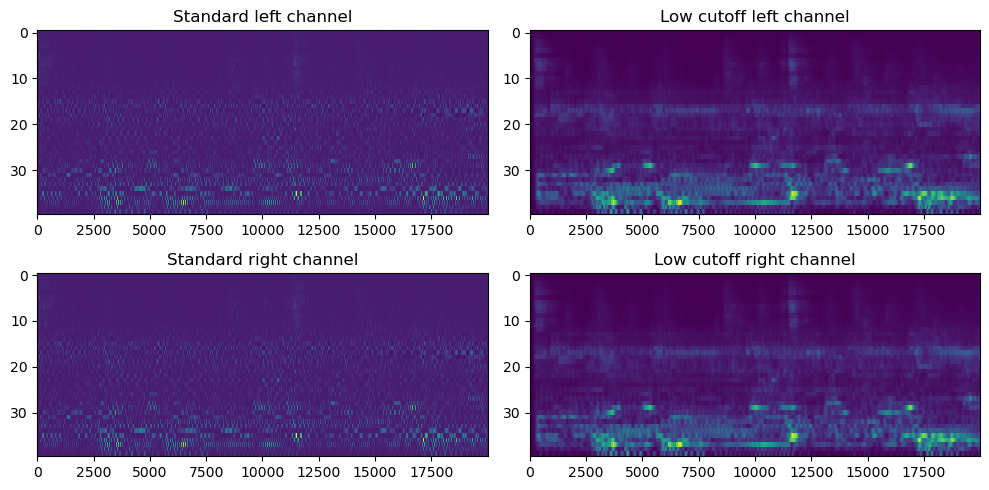

In [24]:
# plot left and right channels as panels
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(std_coch.squeeze()[0,:], aspect='auto', interpolation='none')
plt.title('Standard left channel')
plt.subplot(2, 2, 3)
plt.imshow(std_coch.squeeze()[1,:], aspect='auto', interpolation='none')
plt.title('Standard right channel')

plt.subplot(2, 2, 2)
plt.imshow(lc_coch.squeeze()[0,:], aspect='auto', interpolation='none')
plt.title('Low cutoff left channel')
plt.subplot(2, 2, 4)
plt.imshow(lc_coch.squeeze()[1,:], aspect='auto', interpolation='none')
plt.title('Low cutoff right channel')

plt.tight_layout()